## Engranes y poleas


In [2]:
import numpy as np
import matplotlib.pyplot as plt
P_motriz=10 #[HP]
rpm_motor= 120 #[rpm]
N_f=1.6
print(f'la potencia motriz es de {P_motriz*746}')
d_b=0.06 #[m]
d_c=0.12 #[m]
d_d=0.15 #[m]
d_e=0.05 #[m]
d_f=0.18 #[m]
d_g=0.08 #[m]
d_eje=0.04#[m]

theta=20*np.pi/180
theta_DE=np.asin((d_d/2-d_e/2)/0.5) #distancia de D a E es de 500 mm
theta_FG=np.asin((d_f/2-d_g/2)/0.6) #distancia de F a G es de 600 mm
beta_DE=np.pi-2*theta_DE
beta_FG=np.pi-2*theta_FG
print(f'theta DE={theta_DE} rad ó {theta_DE*180/np.pi}°')
print(f'theta FG={theta_FG} rad ó {theta_FG*180/np.pi}°')
u_s=0.3

la potencia motriz es de 7460
theta DE=0.10016742116155979 rad ó 5.739170477266786°
theta FG=0.083430086610615 rad ó 4.780191847199159°


- M : Momento
- F : Fuerza
- R : Reacción de fuerza
- T : Tensión
- _X: en X
- _X(x ó Y): eje de coordenada x o y
- _X(1 ó 2): 1>2

**Marco de referencia (mano derecha):** X hacia la polea G (derecha en los DCL de poleas), Y hacia arriba,
Z a lo largo del eje, del lado motor hacia F (sale de la hoja en los DCL de poleas). Origen en el apoyo 1.
Giro del eje: antihorario visto desde +Z (**+z**). B (motor) gira al revés (**-z**).

**Convención de las R de las poleas:** `R_*` = fuerza **del eje sobre la polea** (la de tu DCL de polea), con signo según los ejes globales.
Sobre el eje actúa `-R_*` (acción-reacción).

![WhatsApp Image 2026-10-03 at 5.10.20 PM.jpeg](<attachment:WhatsApp Image 2026-10-03 at 5.10.20 PM.jpeg>)
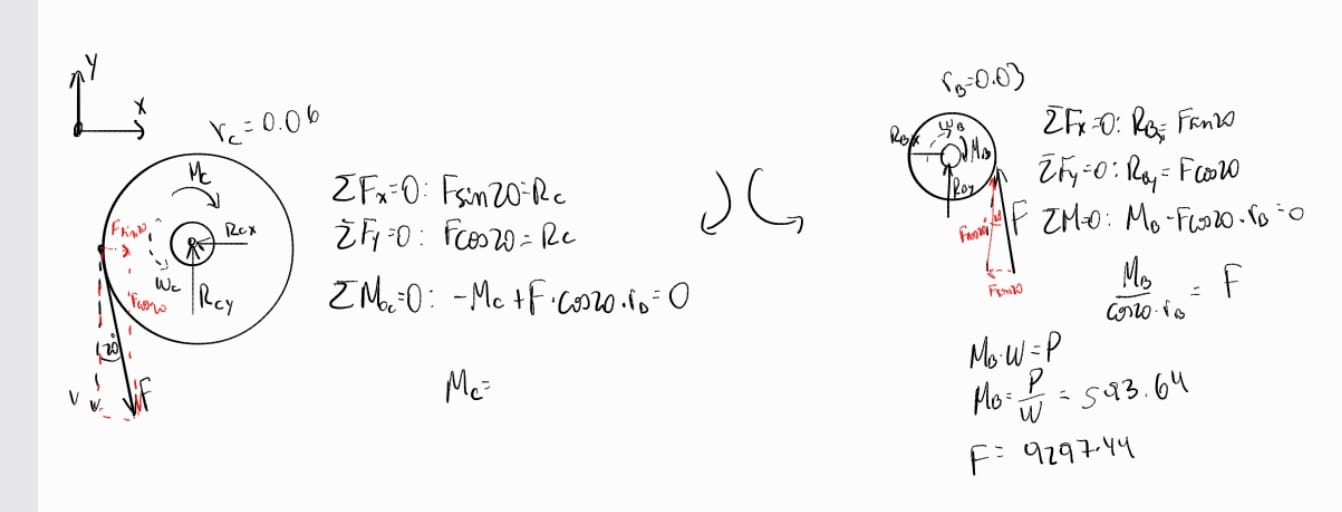

### Engranes B/C
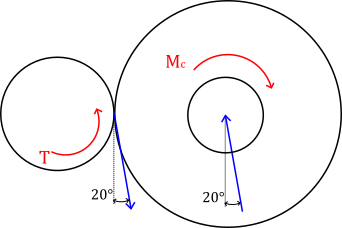


In [3]:
#DCL ENGRANES B-C
M_B = P_motriz*746/(rpm_motor*np.pi/30)        # [N·m] par del motor sobre B
F   = M_B/(np.cos(theta)*d_b/2)                # [N] fuerza total sobre el diente (tangencial/cos20)
# DCL de C: el diente de B empuja a C en su lado izquierdo con (+F sin20, -F cos20)
# Reacción del EJE sobre C (equilibrio):
R_CX = -F*np.sin(theta)                        # [N] hacia la izquierda
R_CY = +F*np.cos(theta)                        # [N] hacia arriba
M_C  =  F*np.cos(theta)*d_c/2                  # [N·m] magnitud; el eje lo aplica horario (-z) sobre C
print(f'M_B = {M_B:.1f} N·m | F = {F:.0f} N')
print(f'C: R_CX = {R_CX:.0f} N, R_CY = {R_CY:.0f} N, M_C = {M_C:.1f} N·m')

M_B = 593.6 N·m | F = 21058 N
C: R_CX = -7202 N, R_CY = 19788 N, M_C = 1187.3 N·m


In [4]:
#POTENCIA EN EJE
omega_B= -rpm_motor*2*np.pi/60 #[rad /s] signo quiere decir z negativo
omega_C=-omega_B*d_b/d_c #[rad/s]
omega_eje=omega_C
P_eje=omega_eje*M_C
#Consideración de momentos que se llevan las poleas
P_D=0.5*P_eje #Si potencia en polea D es del 50%
P_F=P_eje-P_D
M_D=P_D/omega_eje #Por si P_D no es 0.5, los momentos de torsion cambiaran
M_F=P_F/omega_eje #lo mismo aca
print(P_D,P_F, M_D,M_F)
print(f'{P_eje} W') #Confirmado que da la misma potencia en W que la potencia que se entrega en el motor

3730.0 3730.0 593.6479377327697 593.6479377327697
7460.0 W


![WhatsApp Image 2026-10-03 at 5.11.40 PM.jpeg](<attachment:WhatsApp Image 2026-10-03 at 5.11.40 PM.jpeg>)
![WhatsApp Image 2026-10-03 at 5.12.29 PM.jpeg](<attachment:WhatsApp Image 2026-10-03 at 5.12.29 PM.jpeg>)
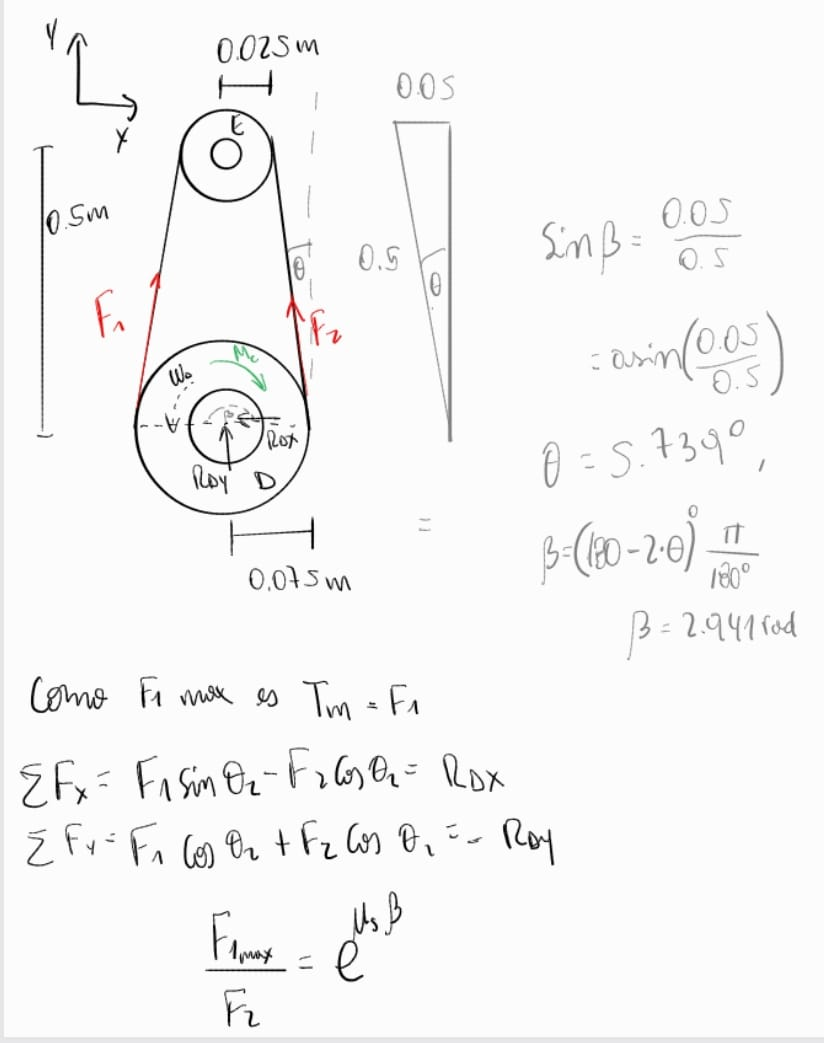
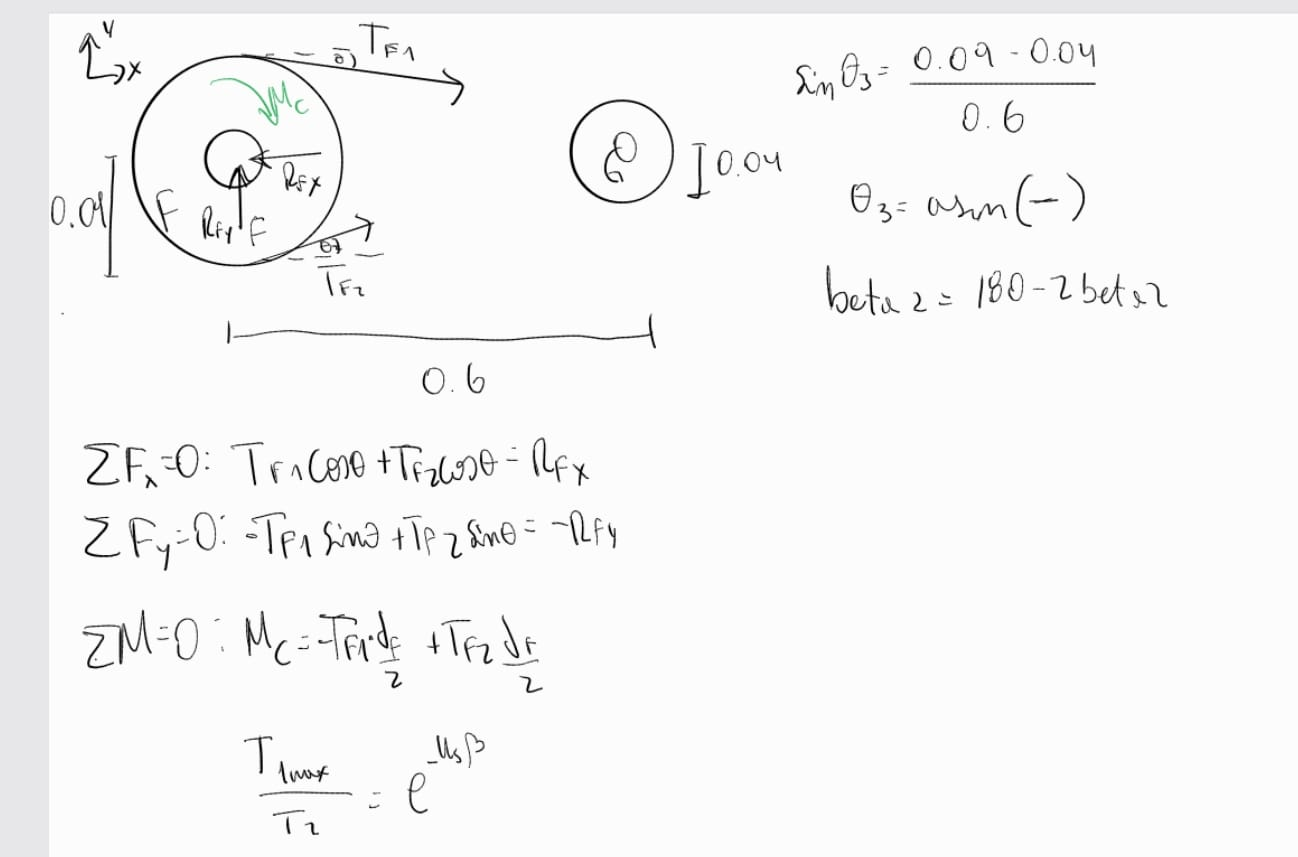

In [5]:
#DCL POLEAS D y F  (T1 = lado tenso, T2 = lado flojo; magnitudes positivas)
k_DE, k_FG = np.exp(u_s*beta_DE), np.exp(u_s*beta_FG)   # beta = pi - 2*theta (polea chica manda el deslizamiento)

# Polea D (lado tenso a la izquierda; ambos ramales suben hacia E, inclinados hacia el centro)
T_D2 = M_D/((k_DE-1)*d_d/2);  T_D1 = k_DE*T_D2
F_belt_D = np.array([ (T_D1-T_D2)*np.sin(theta_DE),  (T_D1+T_D2)*np.cos(theta_DE)])   # correa SOBRE D
R_DX, R_DY = -F_belt_D                                                                 # eje SOBRE D

# Polea F (lado tenso arriba; ambos ramales van hacia G, el de arriba baja y el de abajo sube)
T_F2 = M_F/((k_FG-1)*d_f/2);  T_F1 = k_FG*T_F2
F_belt_F = np.array([ (T_F1+T_F2)*np.cos(theta_FG),  (T_F2-T_F1)*np.sin(theta_FG)])   # correa SOBRE F
R_FX, R_FY = -F_belt_F                                                                 # eje SOBRE F

print(f'D: T1={T_D1:.0f} N, T2={T_D2:.0f} N | R_DX={R_DX:.0f} N, R_DY={R_DY:.0f} N')
print(f'F: T1={T_F1:.0f} N, T2={T_F2:.0f} N | R_FX={R_FX:.0f} N, R_FY={R_FY:.0f} N')
# Chequeo de par: (T1-T2)*r debe valer M
print('chequeo M_D, M_F:', (T_D1-T_D2)*d_d/2, (T_F1-T_F2)*d_f/2)

D: T1=13503 N, T2=5587 N | R_DX=-792 N, R_DY=-18994 N
F: T1=11173 N, T2=4577 N | R_FX=-15696 N, R_FY=550 N
chequeo M_D, M_F: 593.6479377327698 593.6479377327696


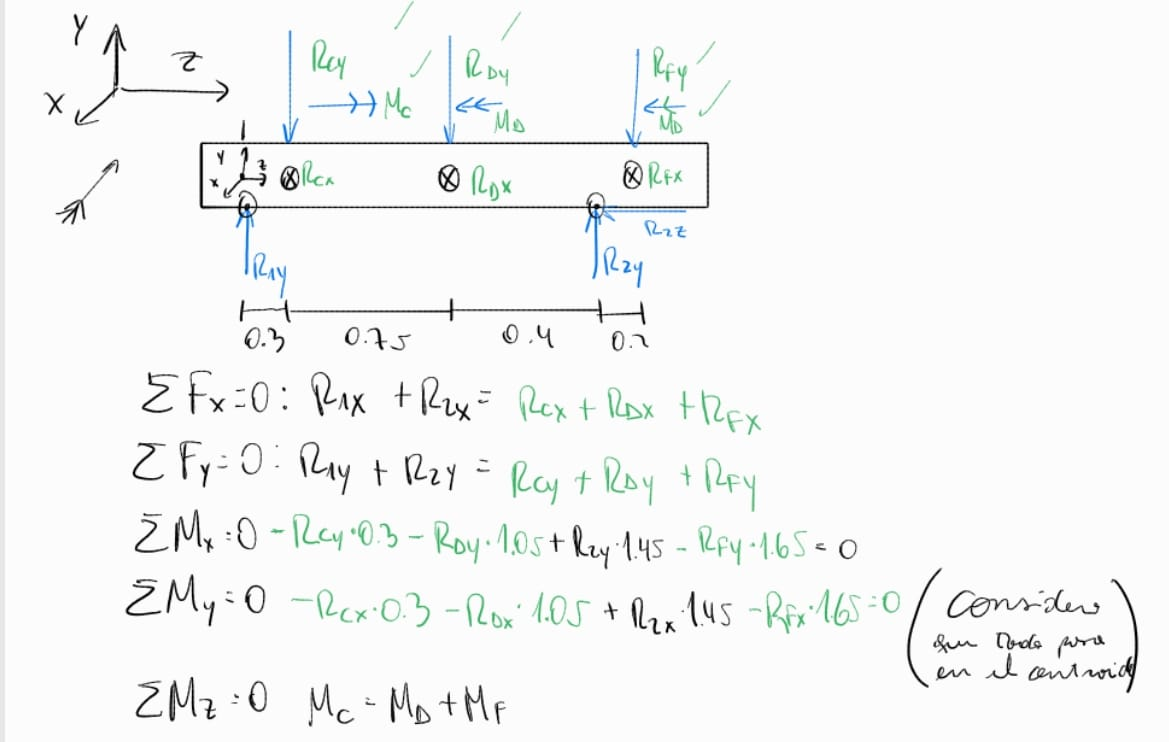

## Eje: reacciones, cortante, flector y torsor
Cargas sobre el eje = `-R` de cada polea. Apoyo 1 en z=0 (solo X,Y), apoyo 2 en z=1.45 m (X,Y,Z). Eje Z = eje del árbol: las fuerzas en X **y** en Y son transversales, cada una flecta en su propio plano.

Apoyo 1: R_S1X=-3766 N, R_S1Y=10378 N
Apoyo 2: R_S2X=-19924 N, R_S2Y=-9035 N, R_S2Z=0 N
chequeo final: M_xz=-9.09e-13, M_yz=1.36e-12 N·m, T=0.00e+00 N·m, ΣMz=0.00e+00
M_res máx = 4201 N·m en z = 1.05 m | T máx = 1187.3 N·m


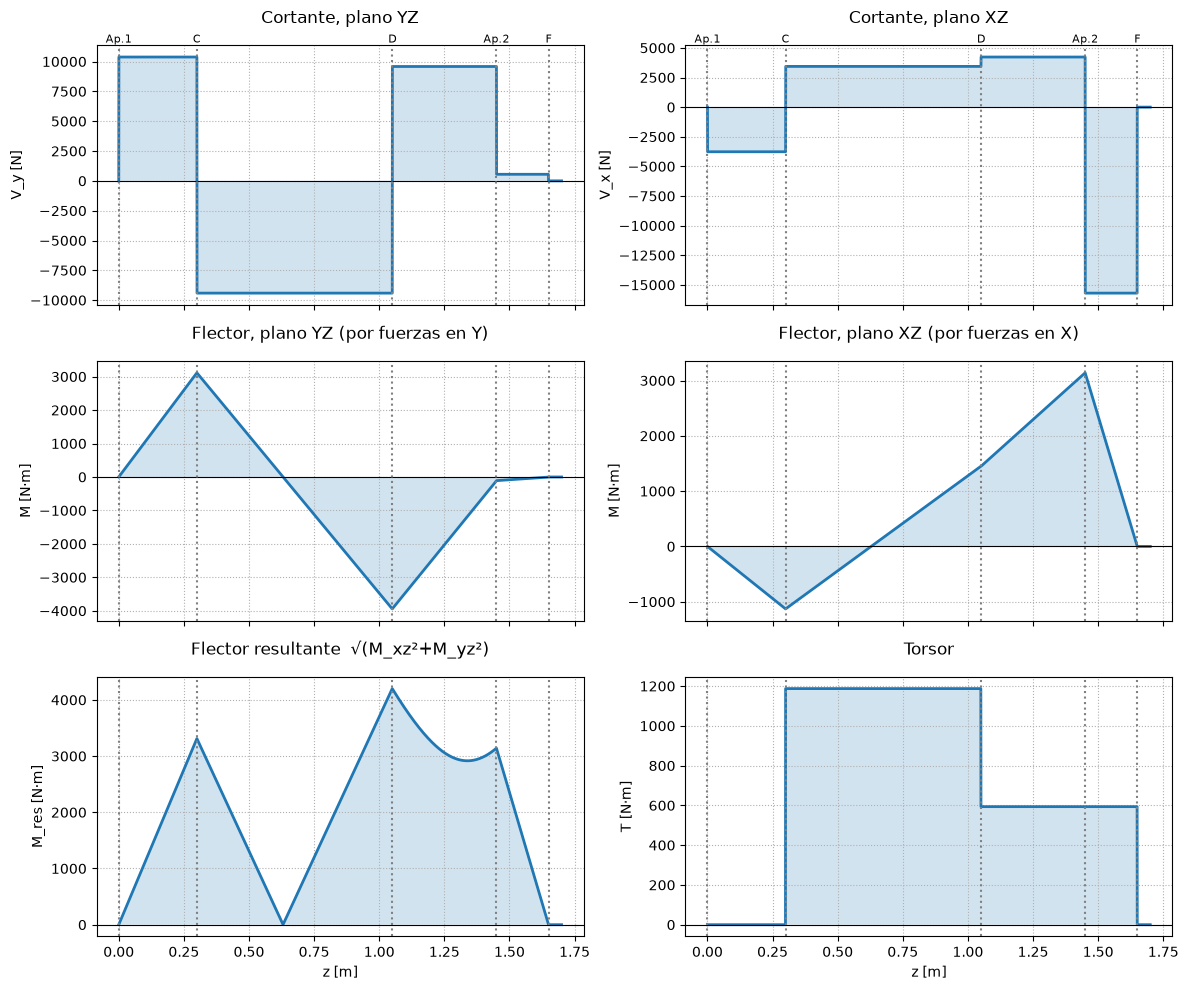

In [6]:
# ===== EJE: cargas -> reacciones -> diagramas =====
# 1) Geometría [m] (origen en el apoyo 1) y largo del eje (AJUSTA L al real)
z1, zC, zD, z2, zF, L = 0.0, 0.30, 1.05, 1.45, 1.65, 1.70
marcas = {'Ap.1': z1, 'C': zC, 'D': zD, 'Ap.2': z2, 'F': zF}

# 2) Cargas SOBRE EL EJE [N] (= -R de la polea) y pares sobre el eje [N·m]
zs = np.array([zC, zD, zF])
Fx = -np.array([R_CX, R_DX, R_FX])
Fy = -np.array([R_CY, R_DY, R_FY])
pares = [(zC, +M_C), (zD, -M_D), (zF, -M_F)]          # C entrega (+z); D y F consumen (-z)

# 3) Reacciones (momentos respecto al apoyo 1). ΣM_x: -Σz·Fy - z2·R2y = 0 ; ΣM_y: Σz·Fx + z2·R2x = 0
R_S2Y = -np.sum(zs*Fy)/z2
R_S2X = -np.sum(zs*Fx)/z2
R_S1Y = -np.sum(Fy) - R_S2Y
R_S1X = -np.sum(Fx) - R_S2X
R_S2Z = 0.0                                            # ΣF_z = 0: no hay cargas axiales (engranes rectos, correas en plano XY)
print(f'Apoyo 1: R_S1X={R_S1X:.0f} N, R_S1Y={R_S1Y:.0f} N')
print(f'Apoyo 2: R_S2X={R_S2X:.0f} N, R_S2Y={R_S2Y:.0f} N, R_S2Z={R_S2Z:.0f} N')

# 4) Diagramas: V(z) = suma de fuerzas a la izquierda del corte; M(z) = Σ F·(z - z_i) (positivo = cóncavo hacia arriba)
fuerzas = [(zi, fx, fy) for zi, fx, fy in zip(zs, Fx, Fy)] + [(z1, R_S1X, R_S1Y), (z2, R_S2X, R_S2Y)]
z = np.linspace(0, L, 3401)
def diag(i):                                           # i=1 -> plano XZ, i=2 -> plano YZ
    V = sum(f[i]*(z > f[0]) for f in fuerzas)
    M = sum(f[i]*np.clip(z - f[0], 0, None) for f in fuerzas)
    return V, M
Vx, Mxz = diag(1)
Vy, Myz = diag(2)
M_res = np.hypot(Mxz, Myz)                             # flector resultante
T = sum(m*(z >= zi) for zi, m in pares)                # torsor interno

# 5) Chequeos: el flector y el torsor deben volver a 0 al final del eje
print(f'chequeo final: M_xz={Mxz[-1]:.2e}, M_yz={Myz[-1]:.2e} N·m, T={T[-1]:.2e} N·m, ΣMz={M_C-M_D-M_F:.2e}')
i = np.argmax(M_res)
print(f'M_res máx = {M_res[i]:.0f} N·m en z = {z[i]:.2f} m | T máx = {T.max():.1f} N·m')

# 6) Gráficos
fig, ax = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
paneles = [(ax[0,0], Vy,    'V_y [N]',      'Cortante, plano YZ'),
           (ax[0,1], Vx,    'V_x [N]',      'Cortante, plano XZ'),
           (ax[1,0], Myz,   'M [N·m]',      'Flector, plano YZ (por fuerzas en Y)'),
           (ax[1,1], Mxz,   'M [N·m]',      'Flector, plano XZ (por fuerzas en X)'),
           (ax[2,0], M_res, 'M_res [N·m]',  'Flector resultante  √(M_xz²+M_yz²)'),
           (ax[2,1], T,     'T [N·m]',      'Torsor')]
for a, d, yl, tit in paneles:
    a.plot(z, d, lw=2); a.fill_between(z, d, alpha=.2); a.axhline(0, c='k', lw=.8)
    for nombre, zi in marcas.items():
        a.axvline(zi, ls=':', c='gray')
    a.set_ylabel(yl); a.set_title(tit, pad=16); a.grid(True, ls=':')
for a in ax[0]:                                        # nombres de los puntos arriba
    for nombre, zi in marcas.items():
        a.text(zi, a.get_ylim()[1], nombre, ha='center', va='bottom', fontsize=8)
for a in ax[2]: a.set_xlabel('z [m]')
plt.tight_layout(); plt.show()